In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clean_dataset.csv")

In [3]:
print("Dataset Shape:", df.shape)
print("Columns:\n", df.columns)


Dataset Shape: (300153, 12)
Columns:
 Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')


In [4]:
df.dropna(inplace=True)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [6]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [9]:
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 2583.0852227743076
R2 Score: 0.9628119256053912


In [12]:
print("Train R2 Score:", model.score(X_train, y_train))
print("Test R2 Score :", model.score(X_test, y_test))

Train R2 Score: 0.9637324765918979
Test R2 Score : 0.9628119256053912


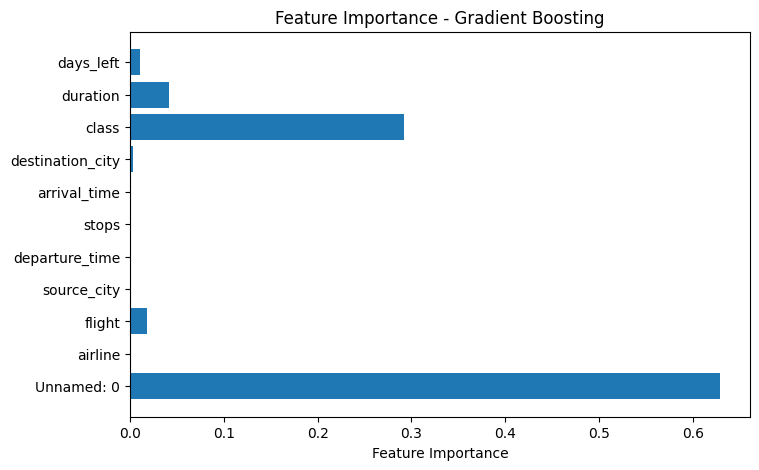

In [13]:
feature_importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, feature_importance)
plt.xlabel("Feature Importance")
plt.title("Feature Importance - Gradient Boosting")
plt.show()